# Robustness comparison — all three methods (Dubins car)

Loads the CSV results produced by:\n- 
`dubins_robustness_vanilla_mpc.ipynb`
`dubins_robustness_ra_mpc.ipynb`
`dubins_robustness_unconstrained.ipynb`
**Disturbance model**: additive position-channel noise only 
`ẋ₁ = v·cos(θ) + d₁,   ẋ₂ = v·sin(θ) + d₂` with `d ~ Uniform[-ε, ε]`
| Level    | ε (m/s) |
|----------|:-------:|
| Nominal  | 0.00    |
| Mild     | 0.10    |
| Moderate | 0.30    |
| Strong   | 0.50    |


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Load CSVs (all three must exist)
df_vanilla = pd.read_csv('robustness_results_vanilla_mpc.csv')
df_ra      = pd.read_csv('robustness_results_ra_mpc.csv')
df_unc     = pd.read_csv('robustness_results_unconstrained.csv')

df_vanilla['method'] = 'Vanilla MPC'
df_ra['method']      = 'RA-MPC'
df_unc['method']     = 'Unconstrained'

df = pd.concat([df_vanilla, df_ra, df_unc], ignore_index=True)
print(f'Total rows: {len(df)}  (3 methods × 4 levels × ~50 ICs)')
print(df.groupby(['method','level'])['success'].count().unstack('level'))

Total rows: 3232  (3 methods × 4 levels × ~50 ICs)
level          mild  moderate  nominal  strong
method                                        
RA-MPC          288       288      288     288
Unconstrained   275       275      275     275
Vanilla MPC     245       245      245     245


In [22]:
# ── Summary table ─────────────────────────────────────────────────────────────
level_order  = ['nominal', 'mild', 'moderate', 'strong']
method_order = ['Vanilla MPC', 'RA-MPC', 'Unconstrained']

agg = df.groupby(['method','level']).agg(
    success_rate=('success', lambda x: round(100*x.sum()/300, 1)),
    mean_ttt=('time_to_target', lambda x: round(x.mean(), 3)),
    mean_min_psi=('min_safety_margin', lambda x: round(x.mean(), 4)),
    n_violations=('n_safety_violations', lambda x: round(x.mean(), 2)),
    mean_effort=('control_effort', lambda x: round(x.mean(), 3)),
).reset_index()

agg['level']  = pd.Categorical(agg['level'],  categories=level_order,  ordered=True)
agg['method'] = pd.Categorical(agg['method'], categories=method_order, ordered=True)
agg = agg.sort_values(['method','level'])

# Pivot for paper-ready table
pivot_sr = agg.pivot(index='level', columns='method', values='success_rate').reindex(level_order)
pivot_psi= agg.pivot(index='level', columns='method', values='mean_min_psi').reindex(level_order)
pivot_ttt= agg.pivot(index='level', columns='method', values='mean_ttt').reindex(level_order)
pivot_vio= agg.pivot(index='level', columns='method', values='n_violations').reindex(level_order)

print('=== Success rate [%] ===')
print(pivot_sr.to_string())
print('\n=== Mean time-to-target [s] (NaN = failed) ===')
print(pivot_ttt.to_string())
print('\n=== Mean minimum safety margin ψ(x) ===')
print(pivot_psi.to_string())
print('\n=== Mean # safety violations (steps with ψ<0) ===')
print(pivot_vio.to_string())

=== Success rate [%] ===
method    Vanilla MPC  RA-MPC  Unconstrained
level                                       
nominal          76.0    86.7           30.7
mild             39.7    41.3           30.3
moderate         39.0    37.7           29.3
strong           32.0    35.3           30.0

=== Mean time-to-target [s] (NaN = failed) ===
method    Vanilla MPC  RA-MPC  Unconstrained
level                                       
nominal         0.908   0.984          5.483
mild            0.722   0.742          5.451
moderate        0.731   0.733          5.384
strong          0.697   0.731          5.309

=== Mean minimum safety margin ψ(x) ===
method    Vanilla MPC  RA-MPC  Unconstrained
level                                       
nominal        1.5452  1.2941         5.9601
mild           1.5238  1.2630         5.6827
moderate       1.4465  1.1331         4.4801
strong         1.3478  1.0246         3.2082

=== Mean # safety violations (steps with ψ<0) ===
method    Vanilla MPC  RA

In [23]:
# ── Save merged CSV and LaTeX-ready summary ───────────────────────────────────
df.to_csv('robustness_summary_table.csv', index=False)
print('Saved robustness_summary_table.csv')

# Combine all four metrics into one multi-index table
combined = pd.concat({
    'Success rate [%]':       pivot_sr,
    'Mean T-to-target [s]':   pivot_ttt,
    'Mean min safety margin': pivot_psi,
    'Mean safety violations': pivot_vio,
}, axis=1)
combined.to_csv('robustness_summary_combined.csv')
print('Saved robustness_summary_combined.csv')
print(combined.to_string())

Saved robustness_summary_table.csv
Saved robustness_summary_combined.csv
         Success rate [%]                      Mean T-to-target [s]                      Mean min safety margin                       Mean safety violations                     
method        Vanilla MPC RA-MPC Unconstrained          Vanilla MPC RA-MPC Unconstrained            Vanilla MPC  RA-MPC Unconstrained            Vanilla MPC RA-MPC Unconstrained
level                                                                                                                                                                            
nominal              76.0   86.7          30.7                0.908  0.984         5.483                 1.5452  1.2941        5.9601                   0.07   0.12          0.00
mild                 39.7   41.3          30.3                0.722  0.742         5.451                 1.5238  1.2630        5.6827                   0.49   0.55          0.36
moderate             39.0   37.7     

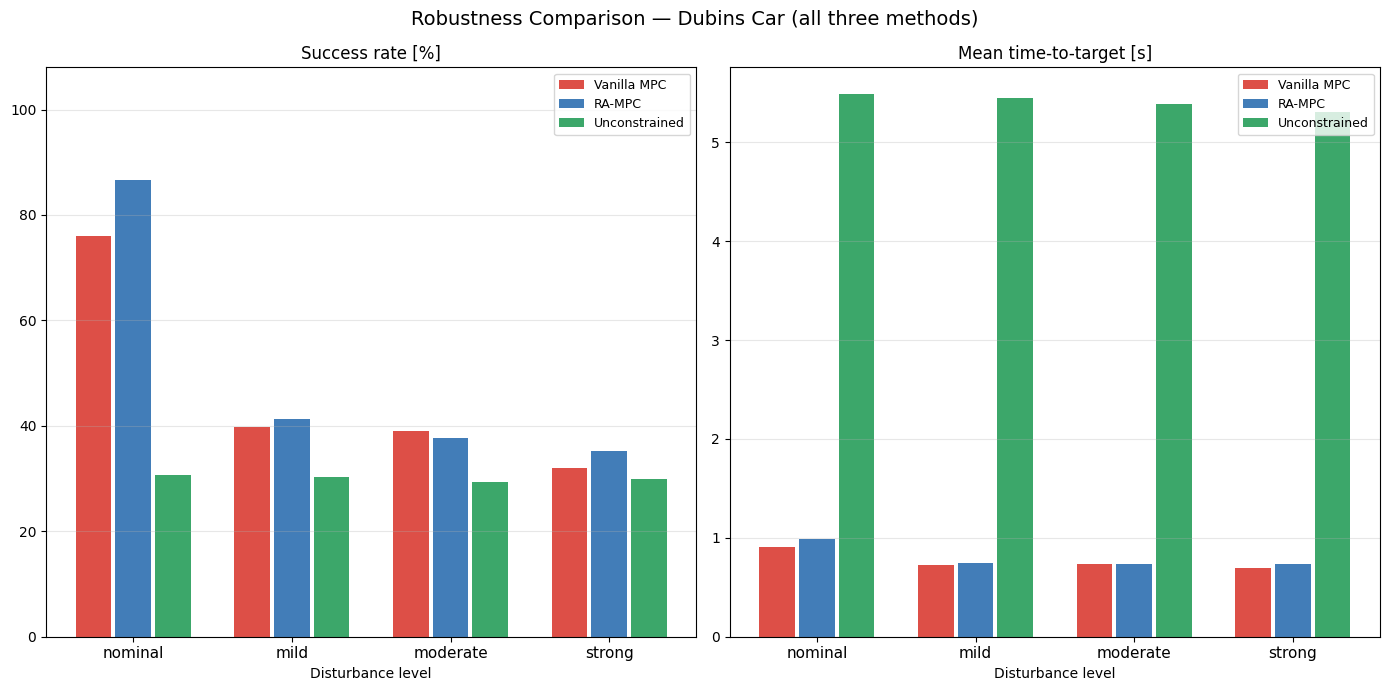

Figure saved: fig_robustness_comparison.png


In [29]:
# ── Comparison figure ─────────────────────────────────────────────────────────
colors_m = {'Vanilla MPC': '#d73027', 'RA-MPC': '#2166ac', 'Unconstrained': '#1a9850'}
markers  = {'Vanilla MPC': 'o', 'RA-MPC': 's', 'Unconstrained': '^'}

x_pos = np.arange(len(level_order))
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle('Robustness Comparison — Dubins Car (all three methods)', fontsize=14)

metrics_plot = [
    ('success_rate',       'Success rate [%]',          axes[0], None),
    ('mean_ttt',           'Mean time-to-target [s]',   axes[1], None),
    # ('mean_min_psi',       'Mean min safety margin ψ',  axes[1, 0], 0.0),
    # ('n_violations',       'Mean # safety violations',  axes[1, 1], None),
]

width = 0.25
offsets = {'Vanilla MPC': -width, 'RA-MPC': 0, 'Unconstrained': width}

for metric, title, ax, hline in metrics_plot:
    for method in method_order:
        subset = agg[agg['method'] == method].sort_values('level').reset_index(drop=True)
        vals = subset[metric].values
        ax.bar(x_pos + offsets[method], vals,
               width=width*0.9,
               label=method,
               color=colors_m[method],
               alpha=0.85)
    if hline is not None:
        ax.axhline(hline, color='red', lw=1.5, ls='--', alpha=0.7)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(level_order, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Disturbance level')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylim(0, 108)
plt.tight_layout()
plt.savefig('fig_robustness_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig_robustness_comparison.png')